# Визуализация анализа комментариев

Интерактивный Jupyter notebook для анализа комментариев к постам по делу Ларисы Долины.

**Функции:**
- Динамика активности комментариев по неделям
- Распределение тональности (позитивная/нейтральная/негативная)
- Взвешенный индекс тональности S(t) с маркерами событий
- Тепловая карта тональности по каналам и месяцам
- Влияние ключевых событий на тональность

**Выход:** PNG графики сохраняются в `results/figures/`

In [1]:
import os
from pathlib import Path

# Определяем корневую папку проекта
current = Path.cwd()
while current != current.parent:
    if (current / "config").exists() and (current / "vizualization").exists():
        project_root = current
        break
    current = current.parent
else:
    project_root = Path.cwd().parent.parent

os.chdir(project_root)
print(f"✓ Рабочая папка: {project_root.name}/")

✓ Рабочая папка: Algorithm/


In [2]:
import sys
from pathlib import Path
from IPython.display import Image, display

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
import logging

# Добавляем проект в sys.path
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

log = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)

In [3]:
from config.settings import (
    COLOR_NEGATIVE,
    COLOR_NEUTRAL,
    COLOR_POSITIVE,
    COLOR_STATE,
    COLOR_PUBLIC,
    EVENTS,
    FIGURE_DPI,
    FIGURE_SIZE_WIDE,
    FIGURES_DIR,
    RESULTS_DIR,
)

In [4]:
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.dpi":        FIGURE_DPI,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
})

sns.set_theme(style="whitegrid", context="notebook", palette="muted")

In [5]:
def _add_event_markers(ax: plt.Axes, events: list[dict] = EVENTS, ymin: float = 0.0, ymax: float = 1.0, 
                       color: str = "#e67e22", alpha: float = 0.7) -> None:
    """Добавляет вертикальные линии ключевых событий на график."""
    for ev in events:
        x = pd.Timestamp(ev["date"], tz="UTC")
        ax.axvline(x=x, color=color, linestyle="--", linewidth=1.0, alpha=alpha)
        ax.text(x, ymax * 0.97, ev["short"], rotation=90, fontsize=7, color=color,
                alpha=0.85, va="top", ha="right",
                bbox={"boxstyle": "round,pad=0.15", "facecolor": "white", 
                      "edgecolor": "none", "alpha": 0.65})


def _save(fig: plt.Figure, name: str) -> Path:
    """Сохраняет фигуру в PNG файл и отображает её в ноутбуке."""
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURES_DIR / f"{name}.png"
    bbox_inches = None if fig.get_constrained_layout() else "tight"
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches=bbox_inches)
    log.info("График сохранён → %s", path)
    plt.close(fig)
    # Отображаем график в ноутбуке
    display(Image(filename=str(path)))
    return path

## Загрузка данных

In [6]:
def _try_load(name: str) -> pd.DataFrame | None:
    """Загружает CSV файл с комментариями, если он существует."""
    path = RESULTS_DIR / f"comments_{name}.csv"
    if path.exists():
        log.info("Загружаем: %s", path)
        return pd.read_csv(path)
    log.warning("Файл не найден: %s", path)
    return None

# Загружаем все доступные данные
print("Загружаю данные комментариев...")
df_act = _try_load("activity_weekly")
df_sent = _try_load("sentiment_weekly")
df_agg = _try_load("by_period_weekly")
df_ch = _try_load("channel_comparison")
df_impact = _try_load("event_impact")

loaded = [df for df in [df_act, df_sent, df_agg, df_ch, df_impact] if df is not None]
print(f"✓ Загружено {len(loaded)} файлов данных")

15:46:14  INFO      Загружаем: /Users/ikuba46/BMSTU/TermWork/Algorithm/results/comments_activity_weekly.csv
15:46:14  INFO      Загружаем: /Users/ikuba46/BMSTU/TermWork/Algorithm/results/comments_sentiment_weekly.csv
15:46:14  INFO      Загружаем: /Users/ikuba46/BMSTU/TermWork/Algorithm/results/comments_by_period_weekly.csv
15:46:14  INFO      Загружаем: /Users/ikuba46/BMSTU/TermWork/Algorithm/results/comments_channel_comparison.csv
15:46:14  INFO      Загружаем: /Users/ikuba46/BMSTU/TermWork/Algorithm/results/comments_event_impact.csv
15:46:14  INFO      Загружаем: /Users/ikuba46/BMSTU/TermWork/Algorithm/results/comments_sentiment_weekly.csv
15:46:14  INFO      Загружаем: /Users/ikuba46/BMSTU/TermWork/Algorithm/results/comments_by_period_weekly.csv
15:46:14  INFO      Загружаем: /Users/ikuba46/BMSTU/TermWork/Algorithm/results/comments_channel_comparison.csv
15:46:14  INFO      Загружаем: /Users/ikuba46/BMSTU/TermWork/Algorithm/results/comments_event_impact.csv


Загружаю данные комментариев...
✓ Загружено 5 файлов данных


## 1. Динамика активности комментариев

15:46:14  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/comments_fig_1_activity_timeline.png


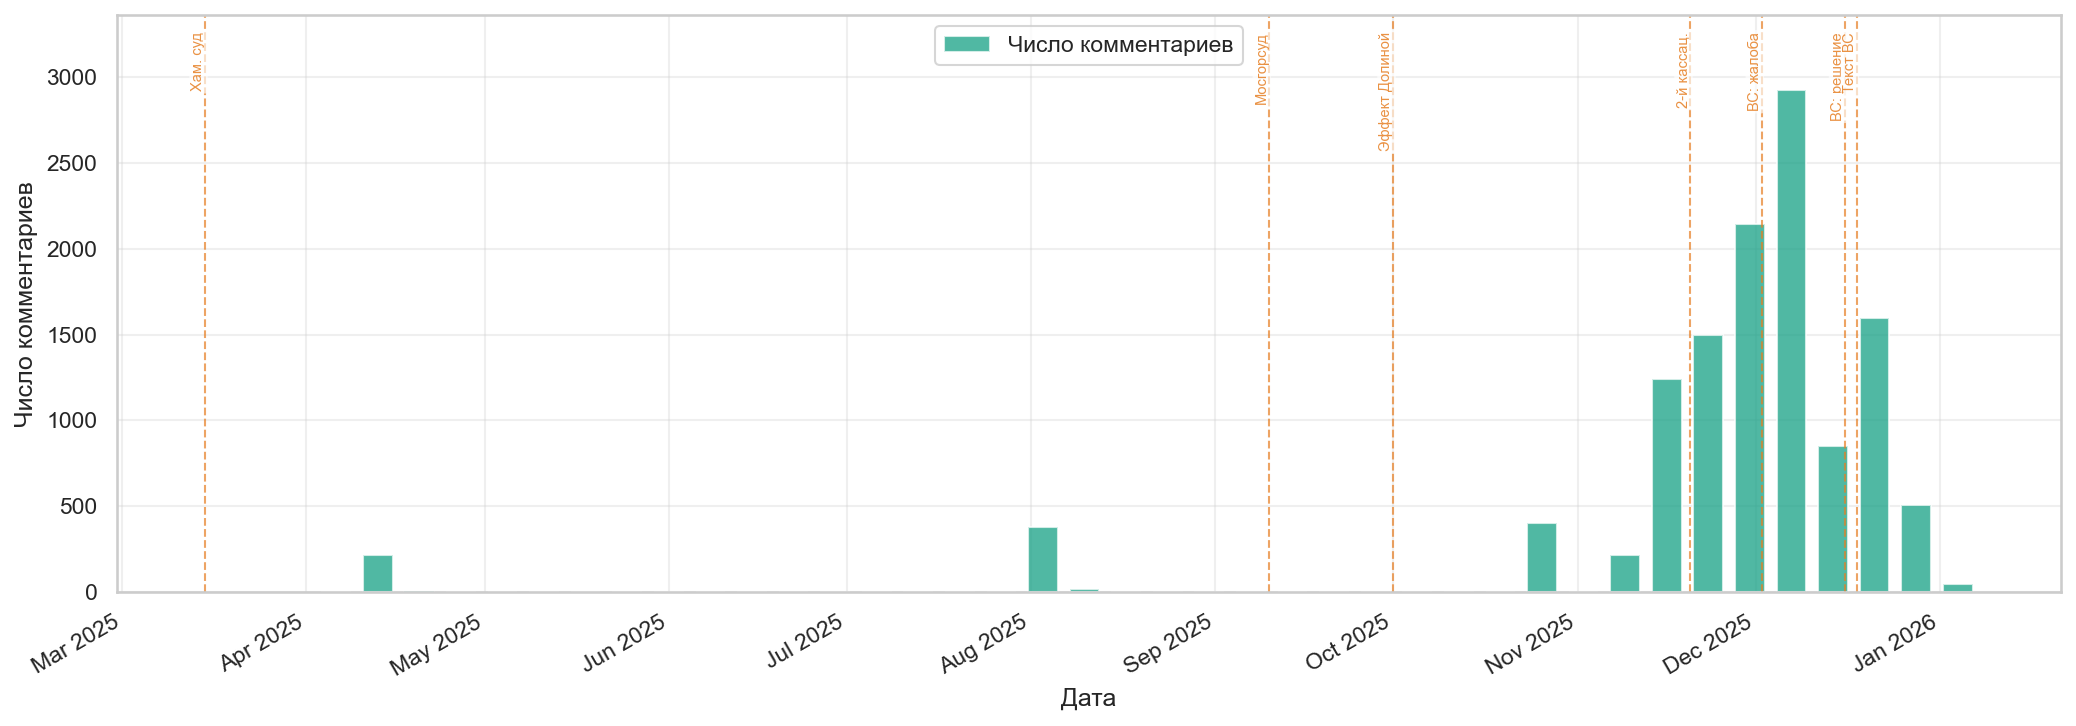

In [7]:
def plot_activity_timeline(df: pd.DataFrame) -> Path:
    """График: количество комментариев по неделям."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)
    df2 = df.copy()
    df2["period"] = pd.to_datetime(df2["period"])

    ax.bar(df2["period"], df2["n_posts"], width=5, color="#16a085", alpha=0.75, label="Число комментариев")
    ax.set_xlabel("Дата")
    ax.set_ylabel("Число комментариев")
    y_max = df2["n_posts"].max() * 1.15
    _add_event_markers(ax, ymax=y_max)
    ax.set_ylim(0, y_max)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=30, ha="right")
    ax.legend()
    fig.tight_layout()
    return _save(fig, "comments_fig_1_activity_timeline")

if df_act is not None:
    plot_activity_timeline(df_act)
else:
    print("Нет данных для графика активности")

## 2. Динамика распределения тональности

15:46:14  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/comments_fig_2_sentiment_timeline.png


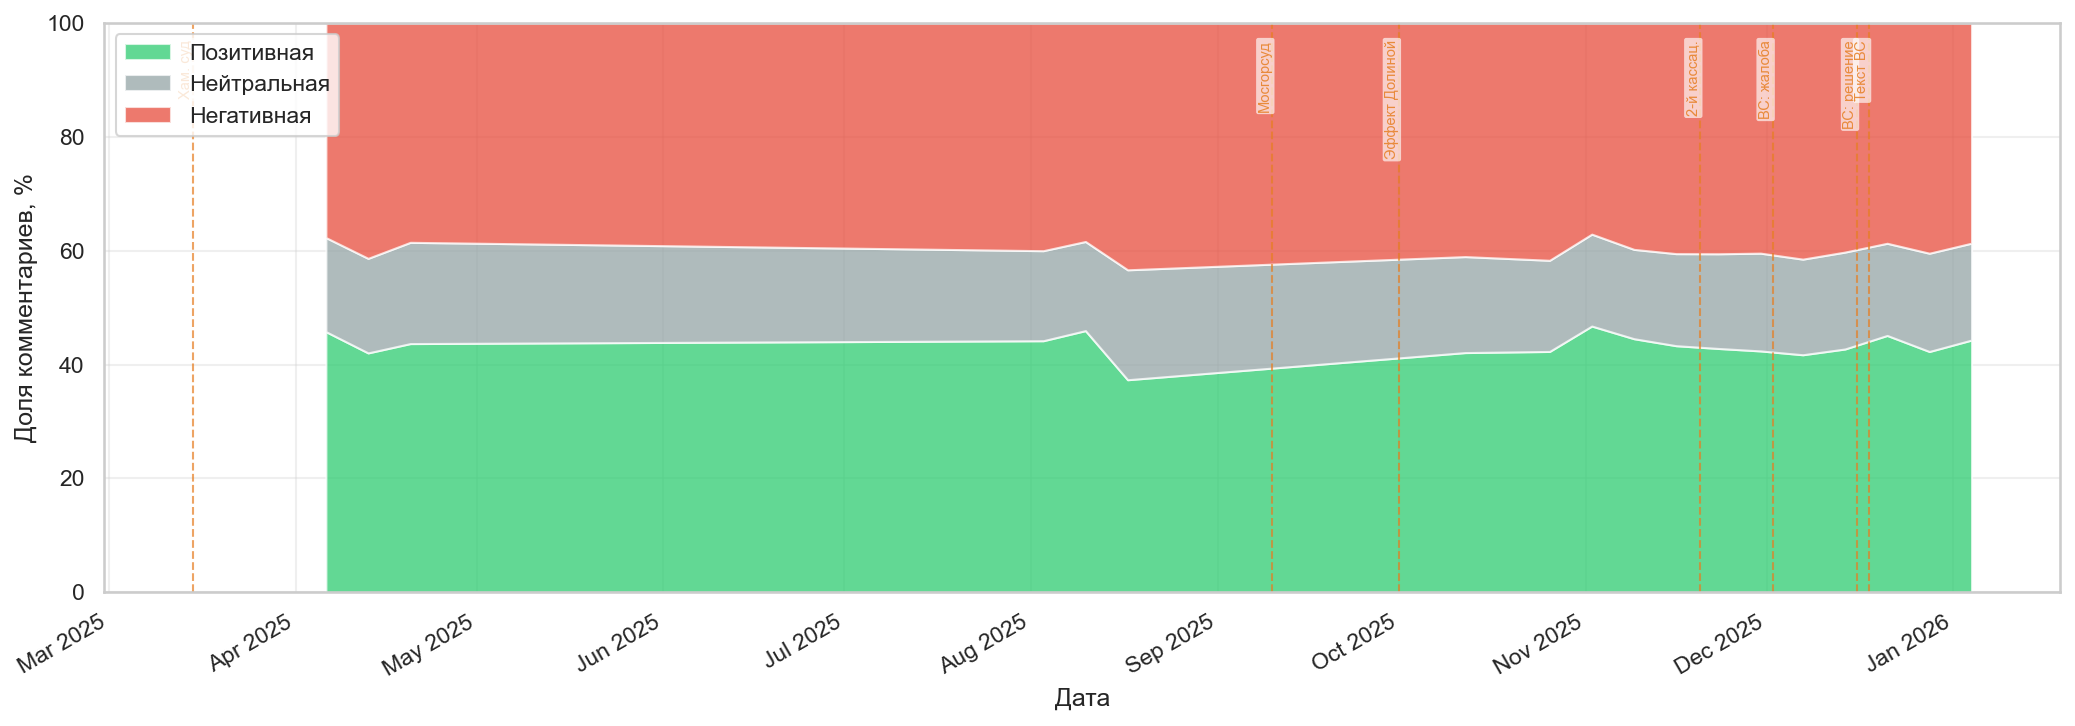

In [8]:
def plot_sentiment_timeline(df: pd.DataFrame) -> Path:
    """График: доля каждого класса тональности (stacked area) по неделям."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)
    df2 = df.copy()
    df2["period"] = pd.to_datetime(df2["period"])
    df2 = df2.sort_values("period")

    ax.stackplot(
        df2["period"],
        df2["pct_positive"],
        df2["pct_neutral"],
        df2["pct_negative"],
        labels=["Позитивная", "Нейтральная", "Негативная"],
        colors=[COLOR_POSITIVE, COLOR_NEUTRAL, COLOR_NEGATIVE],
        alpha=0.75,
    )

    _add_event_markers(ax, ymax=100)
    ax.set_xlabel("Дата")
    ax.set_ylabel("Доля комментариев, %")
    ax.set_ylim(0, 100)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=30, ha="right")
    ax.legend(loc="upper left")
    fig.tight_layout()
    return _save(fig, "comments_fig_2_sentiment_timeline")

if df_sent is not None:
    plot_sentiment_timeline(df_sent)
else:
    print("Нет данных для графика тональности")

## 3. Взвешенный индекс тональности S(t)

15:46:14  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/comments_fig_3_sentiment_index.png


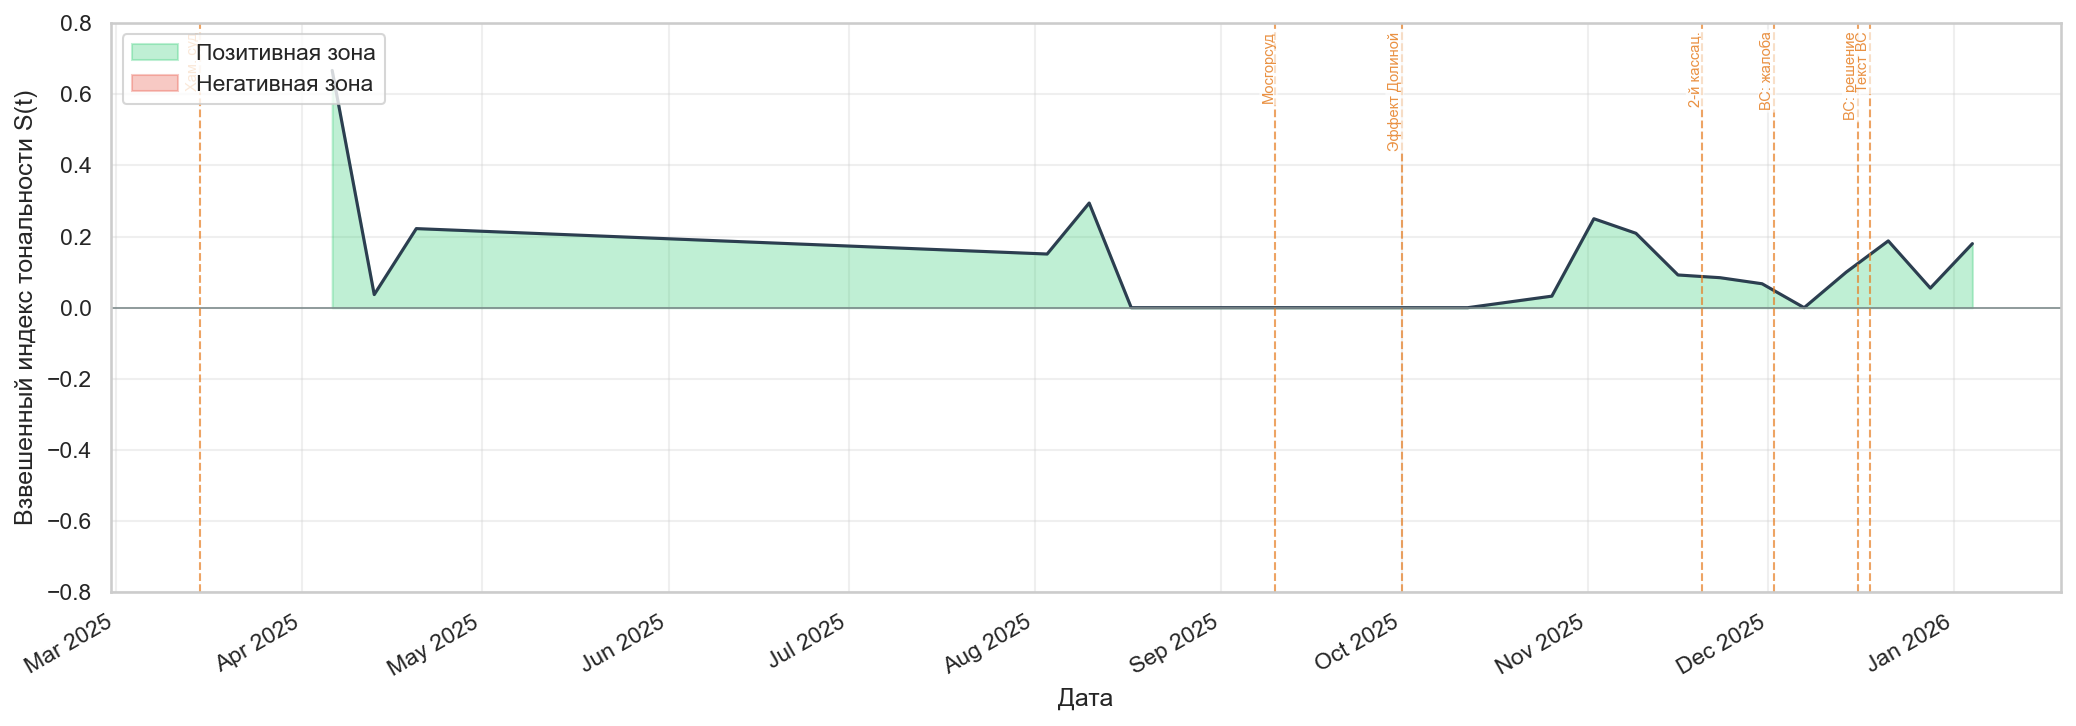

In [9]:
def plot_sentiment_index(df: pd.DataFrame) -> Path:
    """График: взвешенный индекс S(t) с заливкой по зонам."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)
    df2 = df.copy()
    df2["period"] = pd.to_datetime(df2["period"])
    df2 = df2.sort_values("period")

    periods = df2["period"].values
    si = df2["weighted_si"].values

    ax.fill_between(periods, si, 0, where=(si >= 0), alpha=0.3, color=COLOR_POSITIVE, label="Позитивная зона")
    ax.fill_between(periods, si, 0, where=(si < 0), alpha=0.3, color=COLOR_NEGATIVE, label="Негативная зона")
    ax.plot(periods, si, color="#2c3e50", linewidth=1.5)
    ax.axhline(0, color="#7f8c8d", linewidth=0.8, linestyle="-")

    y_abs = max(abs(si).max() * 1.2, 0.1)
    _add_event_markers(ax, ymin=-y_abs, ymax=y_abs)
    ax.set_ylim(-y_abs, y_abs)
    ax.set_xlabel("Дата")
    ax.set_ylabel("Взвешенный индекс тональности S(t)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=30, ha="right")
    ax.legend(loc="upper left")
    fig.tight_layout()
    return _save(fig, "comments_fig_3_sentiment_index")

if df_agg is not None:
    plot_sentiment_index(df_agg)
else:
    print("❌ Нет данных для графика индекса")

## 4. Тепловая карта тональности по каналам

15:46:15  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/comments_fig_4_channel_heatmap.png


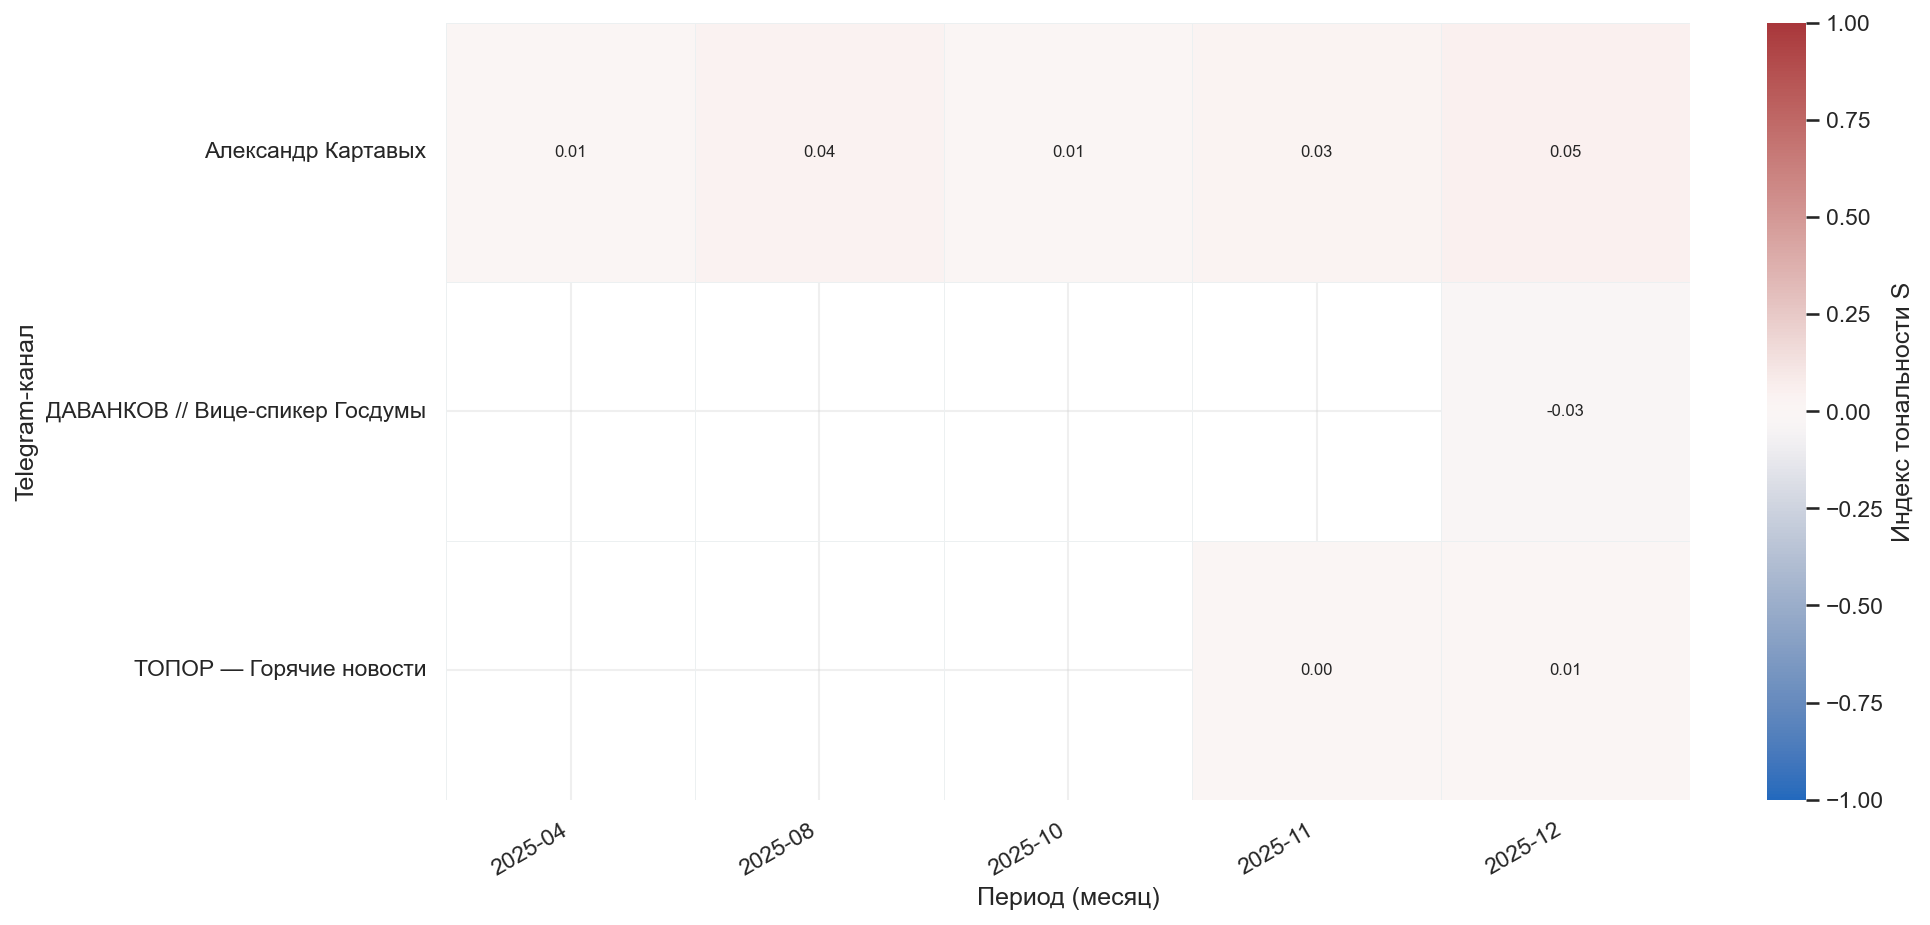

In [10]:
def plot_channel_heatmap(df_wide: pd.DataFrame) -> Path:
    """Тепловая карта: индекс S(t) по каналам и месяцам."""
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.heatmap(
        df_wide.T,
        ax=ax,
        cmap="vlag",
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.4,
        linecolor="#ecf0f1",
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 8},
        cbar_kws={"label": "Индекс тональности S"},
    )
    ax.set_xlabel("Период (месяц)")
    ax.set_ylabel("Telegram-канал")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    fig.subplots_adjust(bottom=0.18, left=0.22, right=0.96, top=0.92)
    return _save(fig, "comments_fig_4_channel_heatmap")

if df_ch is not None:
    df_ch_idx = df_ch.set_index(df_ch.columns[0])
    plot_channel_heatmap(df_ch_idx)
else:
    print("❌ Нет данных для тепловой карты")

## 5. Влияние ключевых событий на тональность

15:46:15  INFO      График сохранён → /Users/ikuba46/BMSTU/TermWork/Algorithm/results/figures/comments_fig_5_event_impact.png


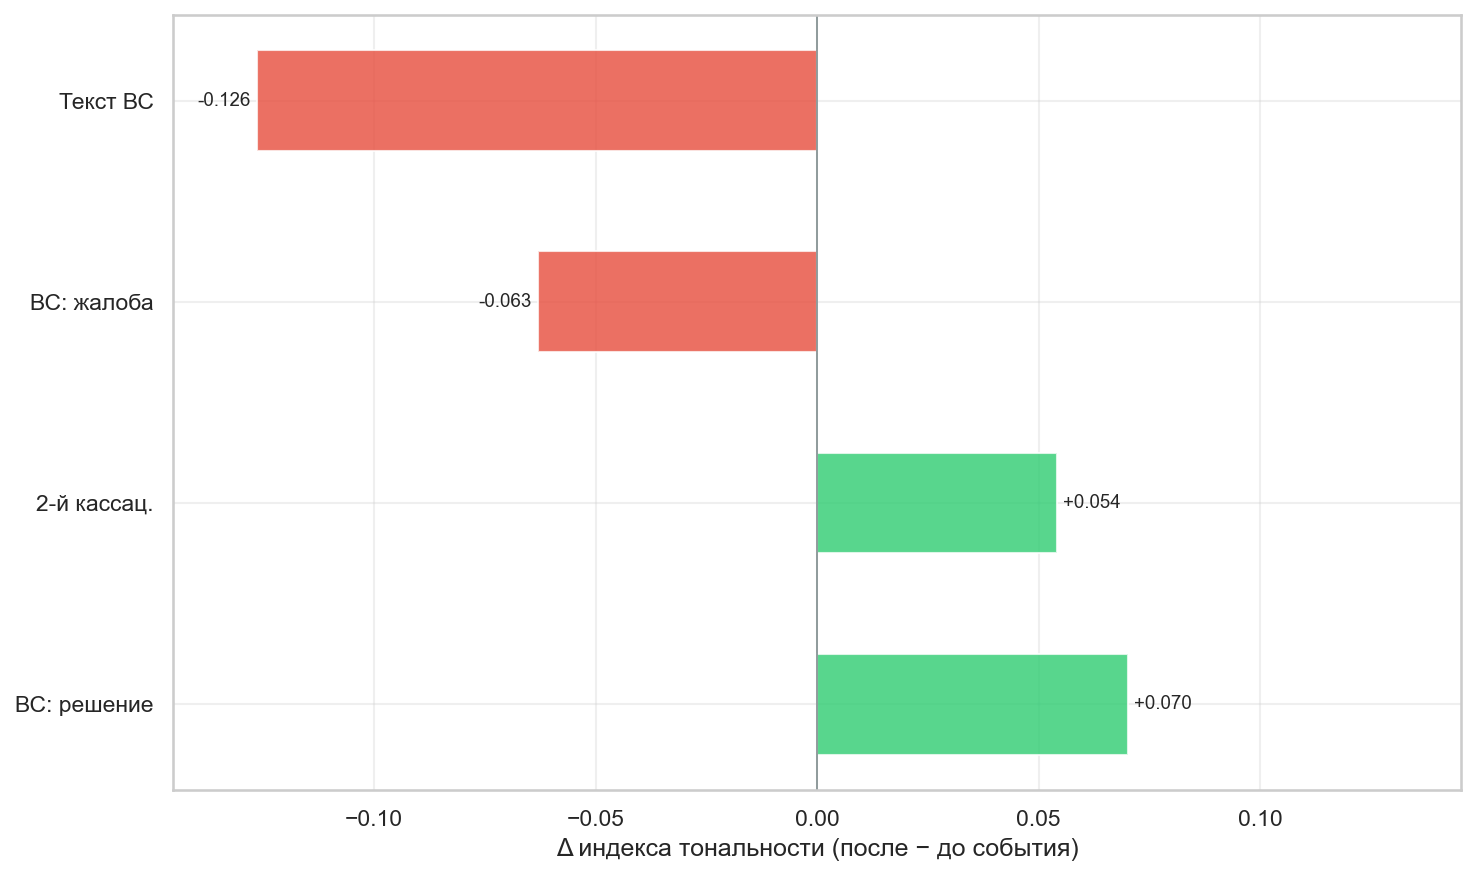

In [11]:
def plot_event_impact(df: pd.DataFrame) -> Path:
    """График: δ тональности (±7 дней вокруг событий)."""
    df2 = df.dropna(subset=["delta"]).copy()
    df2 = df2.sort_values("delta")

    fig, ax = plt.subplots(figsize=(10, 6))

    if df2.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, "Нет данных для оценки влияния событий",
                ha="center", va="center", fontsize=11)
        return _save(fig, "comments_fig_5_event_impact")

    if np.allclose(df2["delta"].values, 0):
        labels = df2["event_label"].astype(str)
        if "n_before" in df2.columns and "n_after" in df2.columns:
            labels = labels + " (n=" + df2["n_before"].astype(int).astype(str) + "/" + df2["n_after"].astype(int).astype(str) + ")"
        y_pos = np.arange(len(df2))
        ax.scatter(np.zeros(len(df2)), y_pos, s=60, color="#7f8c8d", alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels)
        ax.axvline(0, color="#7f8c8d", linewidth=0.8)
        ax.set_xlim(-0.1, 0.1)
        ax.set_xlabel("Δ индекса тональности (после − до события)")
        ax.invert_yaxis()
        ax.grid(axis="x", alpha=0.3)
        fig.tight_layout()
        return _save(fig, "comments_fig_5_event_impact")

    colors = [COLOR_POSITIVE if d >= 0 else COLOR_NEGATIVE for d in df2["delta"]]
    bars = ax.barh(df2["event_label"], df2["delta"], color=colors, alpha=0.8, height=0.5)
    ax.axvline(0, color="#7f8c8d", linewidth=0.8)
    ax.bar_label(bars, fmt="%+.3f", fontsize=9, padding=3)
    ax.set_xlabel("Δ индекса тональности (после − до события)")
    ax.invert_yaxis()
    max_abs = float(np.nanmax(np.abs(df2["delta"])))
    ax.set_xlim(-max_abs * 1.15 if max_abs > 0 else -0.1, max_abs * 1.15 if max_abs > 0 else 0.1)
    fig.tight_layout()
    return _save(fig, "comments_fig_5_event_impact")

if df_impact is not None:
    plot_event_impact(df_impact)
else:
    print("❌ Нет данных для графика влияния событий")

## Запуск всех графиков одной командой

In [12]:
def generate_all_comments_plots() -> list[Path]:
    """Генерирует все 5 типов графиков и сохраняет в PNG."""
    saved = []

    log.info("Генерирую график 1: активность комментариев...")
    try:
        if df_act is not None:
            saved.append(plot_activity_timeline(df_act))
    except Exception as e:
        log.error("График 1 не создан: %s", e)

    log.info("Генерирую график 2: распределение тональности...")
    try:
        if df_sent is not None:
            saved.append(plot_sentiment_timeline(df_sent))
    except Exception as e:
        log.error("График 2 не создан: %s", e)

    log.info("Генерирую график 3: индекс S(t)...")
    try:
        if df_agg is not None:
            saved.append(plot_sentiment_index(df_agg))
    except Exception as e:
        log.error("График 3 не создан: %s", e)

    log.info("Генерирую график 4: тепловая карта по каналам...")
    try:
        if df_ch is not None:
            df_ch_idx = df_ch.set_index(df_ch.columns[0])
            saved.append(plot_channel_heatmap(df_ch_idx))
    except Exception as e:
        log.error("График 4 не создан: %s", e)

    log.info("Генерирую график 5: влияние событий...")
    try:
        if df_impact is not None:
            saved.append(plot_event_impact(df_impact))
    except Exception as e:
        log.error("График 5 не создан: %s", e)

    return saved

print(f"\n✓ Готово! Сохранено {len(paths)} графиков в {FIGURES_DIR}")

NameError: name 'paths' is not defined